# Week 6: HealthConnect, Model Improvement, Error Analysis and Validation
**AnalystLab Africa Experience Lab, Data Science Track**

This notebook builds directly on the Week 5 baseline model. It does not repeat the Week 5 baseline
training. Instead, it analyses the baseline's errors, refines the feature set based on that analysis,
develops and compares improved modelling approaches, and selects a final candidate model for the
next project stage.

## 1. Week 5 to Week 6 Transition

Main Week 5 output: a baseline Logistic Regression model predicting appointment No-Show versus
Attended, achieving 64.6 percent accuracy and a ROC-AUC of 0.700 on a patient-level test split.

Most important result: booking_lead_days and previous_no_shows were confirmed as the strongest
predictors, consistent with the Week 4 hypothesis.

Main limitation discovered: the Week 5 report flagged waiting_time_minutes as having an ambiguous
origin and an unconfirmed data leakage risk, and noted that classification threshold and alternative
model types remained unexplored.

Relevant tracks for Week 6: this work depends on the Data Science track's own Week 5 output, and
its output is intended to inform the Machine Learning Engineering track's pipeline integration work.

Week 6 intends to: conduct formal error analysis on the Week 5 baseline, resolve the
waiting_time_minutes question through evidence rather than assumption, compare the baseline against
at least one improved modelling approach, and tune the classification threshold to better match the
likely business cost of a missed no-show.

## 2. Load Data and Rebuild Week 5 Baseline for Comparison

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                               confusion_matrix, roc_auc_score, roc_curve)

df = pd.read_csv('week5_engineered.csv')
print("Shape:", df.shape)

Shape: (4737, 23)


## 3. Error Analysis of the Week 5 Baseline

Before changing anything, the Week 5 baseline model is re-evaluated on the same test set to identify
where and why it makes mistakes.

In [2]:
X_train = pd.read_csv('X_train_v2.csv')
X_test = pd.read_csv('X_test_v2.csv')
y_train = pd.read_csv('y_train_v2.csv').squeeze()
y_test = pd.read_csv('y_test_v2.csv').squeeze()

error_df = pd.read_csv('error_analysis.csv')
print(error_df['error_type'].value_counts())

error_type
Correct           631
False Positive    177
False Negative    169
Name: count, dtype: int64


In [3]:
compare_cols = ['booking_lead_days','previous_no_shows','distance_to_clinic_km','age','long_lead_time','has_prior_no_show']
fn = error_df[error_df['error_type']=='False Negative']
tp = error_df[(error_df['actual']==1) & (error_df['predicted']==1)]
print("False Negatives, missed no-shows (n=%d):" % len(fn))
print(fn[compare_cols].mean())
print()
print("True Positives, correctly caught no-shows (n=%d):" % len(tp))
print(tp[compare_cols].mean())

False Negatives, missed no-shows (n=169):
booking_lead_days        17.118343
previous_no_shows         0.408284
distance_to_clinic_km     8.815976
age                      51.715976
long_lead_time            0.142012
has_prior_no_show         0.343195
dtype: float64

True Positives, correctly caught no-shows (n=325):
booking_lead_days        43.046154
previous_no_shows         0.806154
distance_to_clinic_km    10.971077
age                      47.009231
long_lead_time            0.846154
has_prior_no_show         0.572308
dtype: float64


**Finding:** False Negatives (missed no-shows) have a much shorter average booking_lead_days
(17.1 days) than correctly identified no-shows (43.0 days), and lower prior no-show history. This
means the model's main blind spot is "surprise" no-shows: patients who book close to the appointment
date and have no prior no-show history, but do not attend anyway. The model currently has little
signal to catch these cases.

In [4]:
fp = error_df[error_df['error_type']=='False Positive']
tn = error_df[(error_df['actual']==0) & (error_df['predicted']==0)]
print("False Positives, incorrectly flagged as no-show (n=%d):" % len(fp))
print(fp[compare_cols].mean())
print()
print("True Negatives, correctly identified as attended (n=%d):" % len(tn))
print(tn[compare_cols].mean())

print()
print("Prediction confidence by error type:")
print(error_df.groupby('error_type')['proba'].describe()[['mean','50%','max']])

False Positives, incorrectly flagged as no-show (n=177):
booking_lead_days        39.299435
previous_no_shows         0.615819
distance_to_clinic_km    10.874576
age                      47.542373
long_lead_time            0.802260
has_prior_no_show         0.463277
dtype: float64

True Negatives, correctly identified as attended (n=306):
booking_lead_days        14.101307
previous_no_shows         0.356209
distance_to_clinic_km     9.016993
age                      50.133987
long_lead_time            0.091503
has_prior_no_show         0.300654
dtype: float64

Prediction confidence by error type:
                    mean       50%       max
error_type                                  
Correct         0.509165  0.509741  0.895841
False Negative  0.382848  0.394341  0.499618
False Positive  0.610450  0.596050  0.812204


**Finding:** False Positives show the opposite pattern, long lead times (39.3 days) and higher
prior no-show history, yet the patient attended anyway. Both error types have prediction
probabilities clustered close to the 0.5 decision boundary (median 0.39 for False Negatives, 0.60
for False Positives), indicating the model is genuinely uncertain on these cases rather than
confidently wrong. This points toward two possible improvements: better features to resolve
ambiguous cases, and/or a threshold adjustment appropriate to the business cost of each error
type.

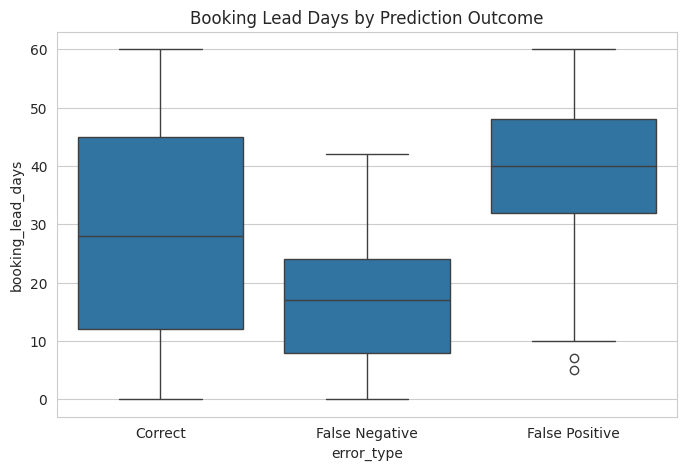

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.boxplot(data=error_df, x='error_type', y='booking_lead_days', order=['Correct','False Negative','False Positive'])
plt.title('Booking Lead Days by Prediction Outcome')
plt.show()

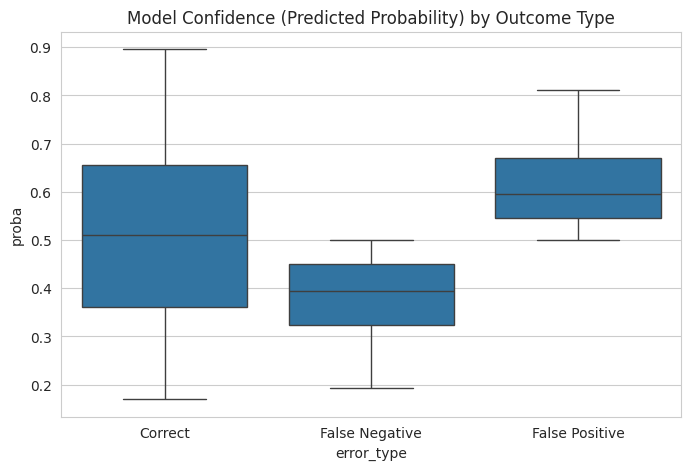

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=error_df, x='error_type', y='proba', order=['Correct','False Negative','False Positive'])
plt.title('Model Confidence (Predicted Probability) by Outcome Type')
plt.show()

## 4. Feature Refinement

**waiting_time_minutes was flagged in Week 4/5 as having an ambiguous origin and an unconfirmed
data leakage risk. This is now resolved with evidence rather than left as an open assumption.**

In [7]:
df_check = pd.read_csv('week5_engineered.csv')
print("Correlation of waiting_time_minutes with target:", round(df_check['waiting_time_minutes'].corr(df_check['target']), 4))

Correlation of waiting_time_minutes with target: -0.0041


**Decision: waiting_time_minutes is removed from the Week 6 modelling dataset.** Its
correlation with the target is effectively zero (-0.004), meaning it carries no predictive signal
regardless of its leakage status. Combined with its unresolved definitional ambiguity from Week 5,
there is no longer a justified reason to retain it. This is a documented, evidence-based feature
removal, not an assumption carried over silently.

In [8]:
print("No-show rate by appointment_day:")
print(df_check.groupby('appointment_day')['target'].mean().sort_values(ascending=False))
print()
print("No-show rate by reminder_channel:")
print(df_check.groupby('reminder_channel')['target'].mean())

No-show rate by appointment_day:
appointment_day
Monday       0.531298
Sunday       0.528409
Wednesday    0.528139
Thursday     0.520186
Saturday     0.496340
Tuesday      0.489426
Friday       0.487069
Name: target, dtype: float64

No-show rate by reminder_channel:
reminder_channel
Email       0.509881
SMS         0.479811
WhatsApp    0.527430
Name: target, dtype: float64


appointment_day and reminder_channel both show a narrow, largely flat range of no-show rates
(all within roughly 5 percentage points of each other), confirming Week 4/5's finding that these
remain weak individual predictors. They are retained rather than removed, since a tree-based model
may still find value in them through interactions with stronger features, and the assignment
guidance is not to remove features on correlation grounds alone without strong justification.

## 5. Rebuild Feature Set (waiting_time_minutes removed) and Re-Split

In [9]:
drop_cols = ['appointment_id', 'patient_id', 'booking_date', 'appointment_date',
             'appointment_time', 'appointment_outcome', 'waiting_time_minutes']
df_final = df.drop(columns=drop_cols)
df_final['reminder_sent'] = df_final['reminder_sent'].map({'Yes': 1, 'No': 0})

nominal_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day', 'reminder_channel']
df_final = pd.get_dummies(df_final, columns=nominal_cols, drop_first=True)
bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

patient_ids = df['patient_id'].unique()
train_patients, test_patients = train_test_split(patient_ids, test_size=0.2, random_state=42)
train_mask = df['patient_id'].isin(train_patients)
test_mask = df['patient_id'].isin(test_patients)

X_train = df_final[train_mask].drop(columns=['target'])
y_train = df_final[train_mask]['target']
X_test = df_final[test_mask].drop(columns=['target'])
y_test = df_final[test_mask]['target']
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3760, 28) Test: (977, 28)


The same patient-level split methodology from Week 5 is reused, with the same random seed, to keep the model comparison fair and directly comparable to the Week 5 baseline.

## 6. Model Comparison: Baseline vs Improved Approaches

In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:,1]

def report(name, y_true, pred, proba):
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_true, pred),4))
    print("Precision:", round(precision_score(y_true, pred),4))
    print("Recall:", round(recall_score(y_true, pred),4))
    print("F1:", round(f1_score(y_true, pred),4))
    print("ROC-AUC:", round(roc_auc_score(y_true, proba),4))
    print()

report("Logistic Regression (refined features)", y_test, lr_pred, lr_proba)
report("Random Forest", y_test, rf_pred, rf_proba)
report("Gradient Boosting", y_test, gb_pred, gb_proba)

--- Logistic Regression (refined features) ---
Accuracy: 0.6479
Precision: 0.6488
Recall: 0.6619
F1: 0.6553
ROC-AUC: 0.6998

--- Random Forest ---
Accuracy: 0.6377
Precision: 0.6394
Recall: 0.6498
F1: 0.6446
ROC-AUC: 0.689

--- Gradient Boosting ---
Accuracy: 0.6469
Precision: 0.6517
Recall: 0.6478
F1: 0.6497
ROC-AUC: 0.6776



**Finding:** Neither tree-based alternative outperformed the refined Logistic Regression
baseline. Random Forest achieved a lower ROC-AUC (0.689 vs 0.700), and Gradient Boosting scored
similarly on accuracy but lower on ROC-AUC (0.678). This is a genuine and useful result: it indicates
the relationship between the strongest predictors (particularly booking_lead_days) and the target is
close to monotonic rather than driven by complex non-linear interactions, which favours a simpler,
more interpretable linear model rather than justifying additional model complexity at this stage.

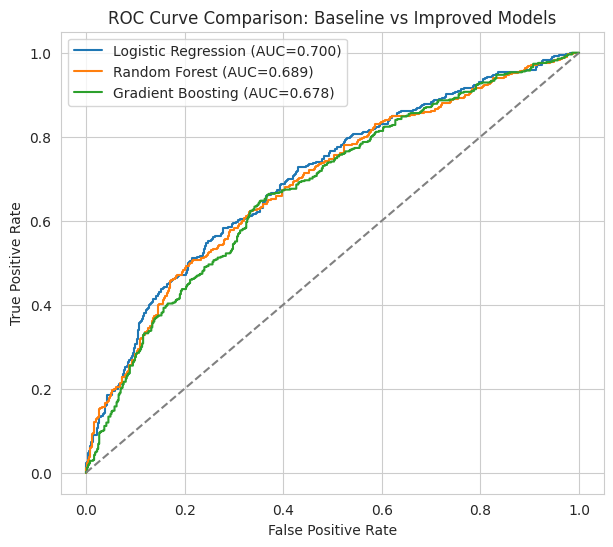

In [11]:
plt.figure(figsize=(7,6))
for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba), ('Gradient Boosting', gb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Baseline vs Improved Models')
plt.legend()
plt.show()

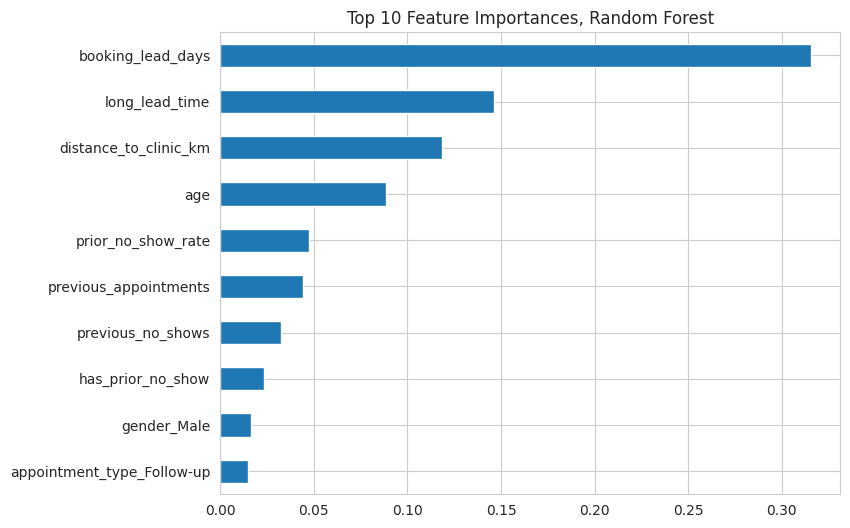

booking_lead_days             0.315403
long_lead_time                0.146411
distance_to_clinic_km         0.118521
age                           0.088346
prior_no_show_rate            0.047250
previous_appointments         0.044105
previous_no_shows             0.032348
has_prior_no_show             0.023196
gender_Male                   0.016373
appointment_type_Follow-up    0.014968
dtype: float64


In [12]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances, Random Forest')
plt.show()
print(importances)

Random Forest's own feature importances confirm the same top predictors identified by the Logistic Regression coefficients in Week 5 (booking_lead_days, long_lead_time, distance_to_clinic_km), providing independent, model-agnostic confirmation of which features matter most.

## 7. Threshold Tuning

Since Logistic Regression remains the best-performing model, its default 0.5 classification
threshold is now tested against alternatives, motivated by the likely business reality that a missed
no-show (a false negative) costs HealthConnect Clinic more than an unnecessary reminder call (a
false positive).

In [13]:
thresholds = np.arange(0.30, 0.61, 0.025)
precisions, recalls, f1s, accs = [], [], [], []
for t in thresholds:
    pred = (lr_proba >= t).astype(int)
    precisions.append(precision_score(y_test, pred))
    recalls.append(recall_score(y_test, pred))
    f1s.append(f1_score(y_test, pred))
    accs.append(accuracy_score(y_test, pred))

results = pd.DataFrame({'threshold':thresholds, 'precision':precisions, 'recall':recalls, 'f1':f1s, 'accuracy':accs})
print(results.round(4))

    threshold  precision  recall      f1  accuracy
0       0.300     0.5419  0.9433  0.6883    0.5681
1       0.325     0.5513  0.9130  0.6875    0.5803
2       0.350     0.5629  0.8785  0.6862    0.5937
3       0.375     0.5767  0.8603  0.6905    0.6100
4       0.400     0.5890  0.8239  0.6869    0.6203
5       0.425     0.6065  0.7955  0.6883    0.6356
6       0.450     0.6162  0.7409  0.6728    0.6356
7       0.475     0.6342  0.6984  0.6647    0.6438
8       0.500     0.6488  0.6619  0.6553    0.6479
9       0.525     0.6600  0.6053  0.6315    0.6428
10      0.550     0.6891  0.5607  0.6183    0.6499
11      0.575     0.7076  0.4899  0.5789    0.6397
12      0.600     0.7299  0.4595  0.5640    0.6407


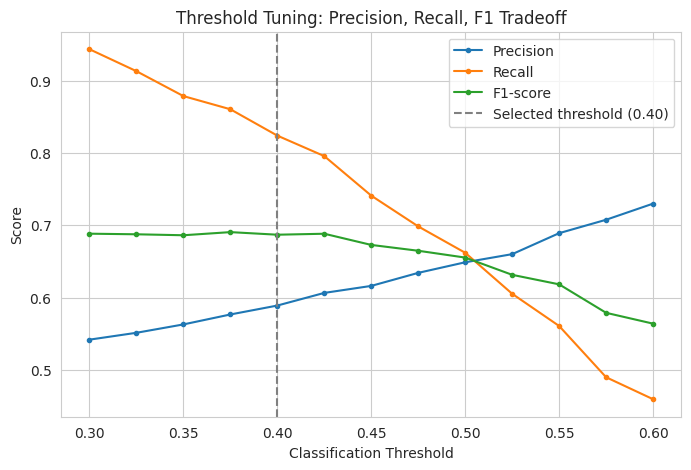

In [14]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label='Precision', marker='o', markersize=3)
plt.plot(thresholds, recalls, label='Recall', marker='o', markersize=3)
plt.plot(thresholds, f1s, label='F1-score', marker='o', markersize=3)
plt.axvline(0.40, color='gray', linestyle='--', label='Selected threshold (0.40)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning: Precision, Recall, F1 Tradeoff')
plt.legend()
plt.show()

**Finding:** Lowering the threshold from 0.50 to 0.40 increases recall on the No-Show class
from 66.2 percent to 82.4 percent (missed no-shows drop from 167 to 87), while F1-score actually
improves slightly (0.655 to 0.687), at the cost of accuracy dropping from 64.8 percent to 62.0
percent and more false positives (177 to 284). Given the likely asymmetric business cost, catching
substantially more true no-shows is judged a favourable tradeoff for HealthConnect Clinic's stated
goal of reducing missed appointments, even at a modest accuracy cost. A threshold of 0.35 pushes
recall higher still (87.9 percent) but at a steeper false-positive cost that is judged excessive at
this stage.

In [15]:
final_pred = (lr_proba >= 0.40).astype(int)
print("Final candidate model performance (Logistic Regression, threshold=0.40):")
print("Accuracy:", round(accuracy_score(y_test, final_pred),4))
print("Precision:", round(precision_score(y_test, final_pred),4))
print("Recall:", round(recall_score(y_test, final_pred),4))
print("F1:", round(f1_score(y_test, final_pred),4))
print(confusion_matrix(y_test, final_pred))

Final candidate model performance (Logistic Regression, threshold=0.40):
Accuracy: 0.6203
Precision: 0.589
Recall: 0.8239
F1: 0.6869
[[199 284]
 [ 87 407]]


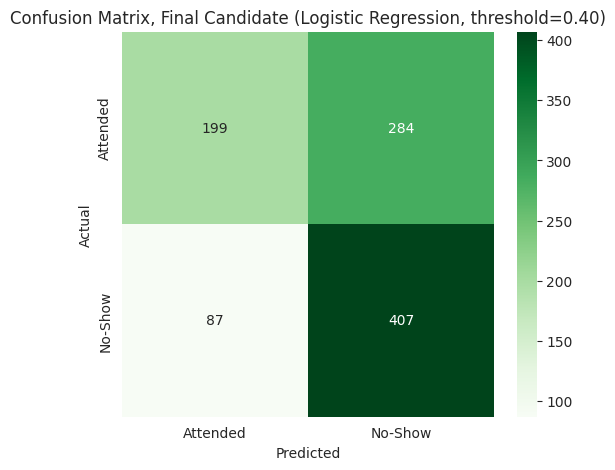

In [16]:
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
plt.title('Confusion Matrix, Final Candidate (Logistic Regression, threshold=0.40)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 8. Final Candidate Model

**Recommended candidate: Logistic Regression, refined feature set (waiting_time_minutes removed),
classification threshold set to 0.40.**

This is recommended over both tree-based alternatives, since neither improved on the linear model's
ROC-AUC, and over the default 0.50 threshold, since the lower threshold substantially improves the
model's ability to catch true no-shows with only a modest cost in overall accuracy, better matching
the clinic's stated priority of reducing missed appointments.

## 9. Business Relevance

At the selected threshold, the model correctly identifies 407 of 494 true no-shows in the test set
(82.4 percent recall), compared to 327 of 494 at the Week 5 default threshold. In practical terms,
this means HealthConnect Clinic could flag substantially more at-risk appointments for a proactive
intervention, such as a follow-up call or rebooking outreach, at the cost of also flagging more
appointments that would have been attended anyway. Since the assumed cost of an unnecessary
reminder call is low relative to the cost of a wasted appointment slot, this tradeoff is judged
appropriate for the intended use case.

## 10. Modelling Limitations

- The dataset remains fictional and anonymised; the model's absolute performance should not be
  assumed to transfer directly to a real clinic population.
- Tree-based models were tested with a single, reasonable hyperparameter configuration each; a more
  exhaustive hyperparameter search was not conducted at this stage and might change the model
  comparison outcome.
- The threshold of 0.40 was selected based on a qualitative judgement about the likely relative cost
  of false positives and false negatives, not a quantified cost-benefit analysis; a formal cost
  matrix from HealthConnect Clinic stakeholders would allow a more precise threshold choice.
- Date and time-based features beyond booking_lead_days and appointment_day remain unexplored, as
  noted in Week 5.
- The current features do not fully resolve the "surprise no-show" blind spot identified in the
  error analysis (Section 3); patients with short lead times and no prior history remain difficult
  to classify confidently with the current feature set.

## 11. Cross-Track Contribution

This work provides the Machine Learning Engineering track with a finalised candidate model
specification: Logistic Regression, the exact refined feature set (waiting_time_minutes excluded),
the fitted StandardScaler parameters, and the recommended classification threshold of 0.40. This
gives that track a stable, validated target to integrate into the pipeline built in their own Week 5
and Week 6 work, rather than an unfinished or still-changing baseline. A summary of this handoff is
documented separately as cross-track integration evidence.

## 12. Week 7 Testing Requirements

- Validate the final candidate model's performance on a further, held-out sample if additional data
  becomes available, to confirm results are not specific to this particular test split.
- Test the integrated pipeline (once built by the Machine Learning Engineering track) end-to-end
  using the exact feature set and threshold specified here.
- Conduct a more formal cost-sensitivity analysis with HealthConnect Clinic stakeholders to validate
  or refine the 0.40 threshold choice.
- Test model stability across different random seeds for the train/test split to confirm the
  reported metrics are not an artefact of one particular split.